<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales - 1C 2026
# Trabajo Práctico Nº 2: Modelizando un ADC
#### Mariano Gonzalez


El ADC que deseamos simular trabajará a una frecuencia de muestreo fS=1000Hz y tendrá un rango analógico de ±VF=2 Volts. Esto nos indica que la señal de entrada debera tener un amplitud pico a pico de 1v (desde -1v hasra 1v) para usar eficientemente el ADC, en caso de usar una amplitud menor estariamos desperdiciando niveles para cuantizar. En el caso contrario, donde la señal supere el pico a pico, nuestro ADC recorta la señal cuantizada ya que no es capas de representar niveles mas alla de su escala.

Se simulará el comportamiento del dispositivo al digitalizar una senoidal contaminada con un nivel predeterminado de ruido. Comenzaremos describiendo los parámetros a ajustar de la senoidal:

- Frecuencia $f0$=$fS/N$=$\Delta$$f$

- Energía normalizada

## Generador de Senoidal y variables globales

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

#%%Generador de senoidal
def mi_funcion_sen( vmax, dc, f0, ph, N, fs):
    tt=np.arange(0,N,1)*(1/fs)
    xx=dc + vmax*np.sin(2*np.pi*f0*tt + ph)
    return tt,xx 

# %% variables globales

#fase= np.pi/2  #fase
fs= 1000 #frecuencia de muestreo
nn=fs #muestra
f0=int(fs/nn) #f0
df=f0 #resolucion espectral
ts=1/fs # periodo muestreo

## Parámetros de la secuencia de ruido y cuantizador

Será de carácter aditivo, es decir la señal que entra al ADC será $sr = s + n$

- Siendo $n$ la secuencia que simula la interferencia, y $s$ la senoidal descrita anteriormente. Por lo tanto la sumatoria la definimos como $sr$

- La potencia del ruido será $Pn = kn \cdot Pq$ siendo el factor $k$ una escala para la potencia del ruido de cuantización $Pq=q^2/12$.

- $n$ será incorrelado y Gaussiano.

- El paso de cuantizacion se define como $q=Vfs/2^b$. Entonces si aumentamos el numero de bits decrece el paso de cuantizacion, logrando una mejor resolucion en nuestro ADC

In [14]:
#%% cuantizador 
b=4 # b-bits
vfs=2 #volts full scale
qq=(vfs)/(2**b) # paso de cuantizacion
pq= (qq**2)/12 # potencia señal
kn=1 #secuencia
pn=kn*pq


In [15]:
#%%Generador de ruido
ruido=np.random.normal(0,np.sqrt(pn),nn) # mu=0, sigma=varianza del ruido de nn muestra

### a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1
En primer lugar vemos un ciclo de las 3 senoidales superpuestas, luego en el segundo grafico hacemos un zoom para que se distinga mejor 

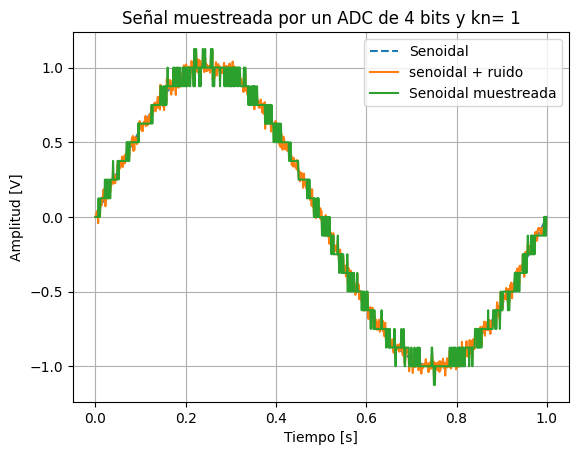

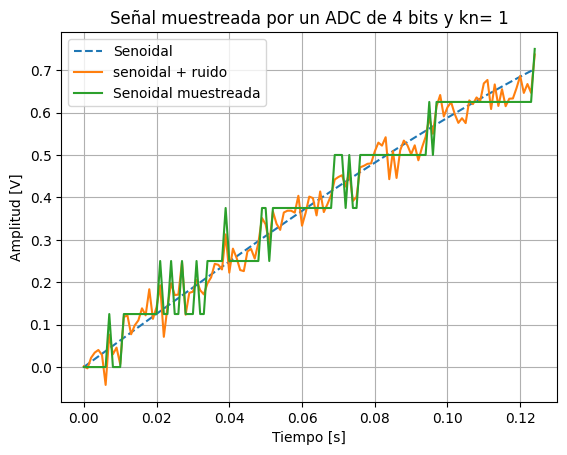

In [16]:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, f0 = f0, ph=0,N=nn, fs =fs)

sr = xx + ruido

xxq=np.round(sr/qq) *qq
un_ciclo=int(fs/f0) #para ver de un cliclo completo
plt.figure(1)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()

un_ciclo=int((fs/f0)/8) #zoom para apreciar mejor el efecto 

plt.figure(2)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()




#### Ahora necesitamos graficar la densidad espectral de potencia en dB en funcion de la frecuencia


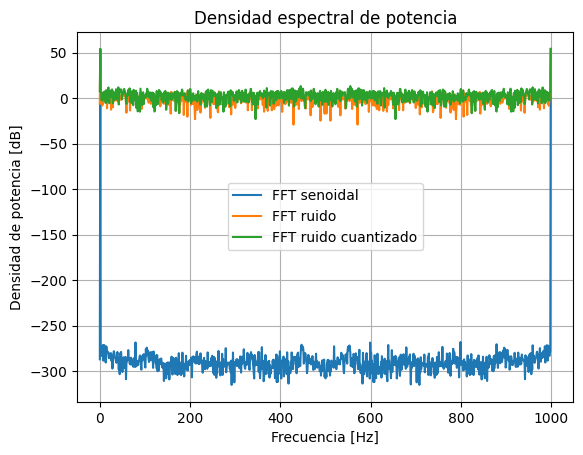

In [17]:
# %% FFTs

# FFT de senoidal limpia
XX=fft(xx)
XXabs=np.abs(XX) 
XXang=np.angle(XX)
XXabs_2=XXabs**2 # densidad espectral 

#FFT de senoidal + ruido
SR=fft(sr)
SRabs=np.abs(SR) 
SRang=np.angle(SR)
SRabs_2=SRabs**2  # densidad espectral

#FTT de senoidal + ruido cuantizada
XXQ=fft(xxq)
XXQabs=np.abs(XXQ) 
XXQang=np.angle(XXQ)
XXQabs_2=XXQabs**2  # densidad espectral

FX= np.arange(nn)*df #defino el eje X en Hertz

plt.figure(3)
plt.clf()
plt.plot(FX,np.log10(XXabs_2)*10, label="FFT senoidal")
plt.plot(FX,np.log10(SRabs_2)*10, label="FFT ruido")
plt.plot(FX,np.log10(XXQabs_2)*10, label="FFT ruido cuantizado")
plt.plot()
plt.grid()
plt.title("Densidad espectral de potencia")
plt.ylabel('Densidad de potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()

#### Histograma de cuantizacion del error

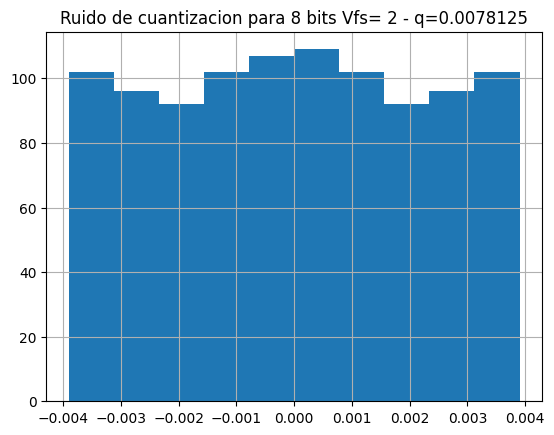

In [26]:
# %% ruido cuantizado

#secuencia de error
xxq=np.round(xx/qq) *qq #quedan en la misma magnitud que la senoidal
ee=xxq-xx #secueencia de error

plt.figure(4)
plt.clf()
plt.grid()
plt.hist(ee)
plt.title(f"Ruido de cuantizacion para {b} bits Vfs= {vfs} - q={qq}")
plt.show()

### b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}
Discutir los resultados respecto a lo obtenido en a). Debajo de cada grafico se discutira resultados

Seleccionamos B=8 y Kn=10

Para entender un poco estos valores: con 8 bits logramos una mayor resolucion en el ADC, en este caso tenemos 256 niveles versus los 16 niveles con 4 bits. Kn=10 estamos aumentando x10 la potencia del ruido

In [33]:
#%% cuantizador 
b=8 # b-bits
vfs=2 #volts - full scale
qq=(vfs)/(2**b) # paso de cuantizacion
pq= (qq**2)/12 # potencia señal
kn=16 #secuencia
pn=kn*pq

In [34]:
#%%Generador de ruido
ruido=np.random.normal(0,np.sqrt(pn),nn) # mu=0, sigma=varianza del ruido de nn muestra

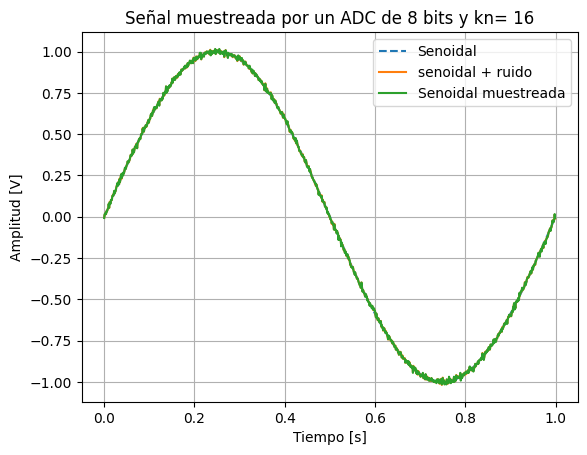

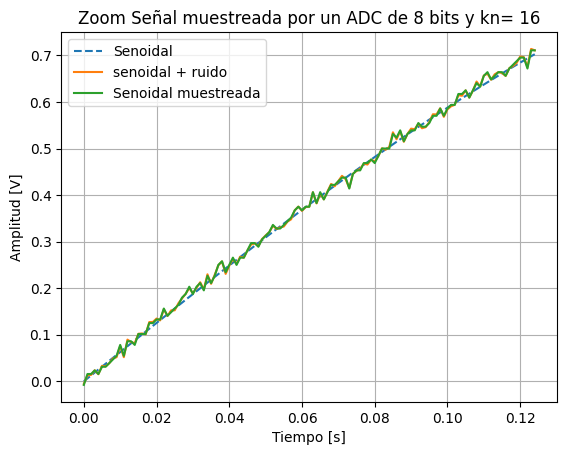

In [35]:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, f0 = f0, ph=0,N=nn, fs =fs)

sr = xx + ruido

xxq=np.round(sr/qq) *qq
un_ciclo=int(fs/f0) #para ver de un cliclo completo
plt.figure(1)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()

un_ciclo=int((fs/f0)/8) #zoom para apreciar mejor el efecto 

plt.figure(2)
plt.clf()
plt.grid()
plt.plot(tt[:un_ciclo],xx[:un_ciclo],'--', label='Senoidal')
plt.plot(tt[:un_ciclo],sr[:un_ciclo], label='senoidal + ruido')
plt.plot(tt[:un_ciclo],xxq[:un_ciclo], label='Senoidal muestreada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title(f"Zoom Señal muestreada por un ADC de {b} bits y kn= {kn}")
plt.legend()
plt.show()

Discucion: se ve claramente que la senoidal cuantizada tiene un mejor aspecto que en el punto a), no es optimo, pero es mejor.
En el segundo grafico con zoom aun se aprecia el ruido. Aumentando la escala de ruido a 10 veces respecto al item a) (Kn=10) estariamos bajando la relacion señal ruido (SNR) y aun asi con el crecimiento de bits el resultado es mejor, se ve una senoidal cuantizada mejor representada.


##### Ahora necesitamos graficar la densidad espectral de potencia en dB en funcion de la frecuencia


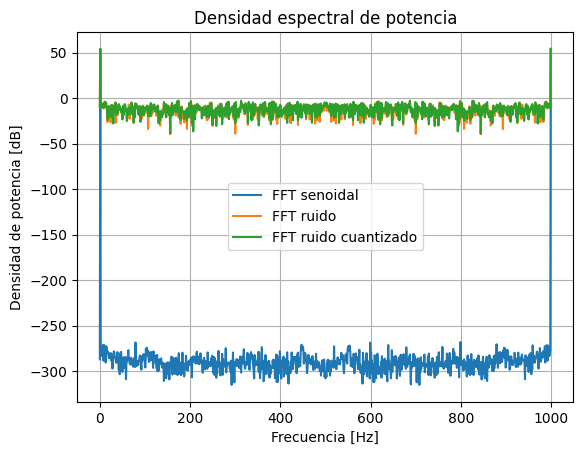

In [36]:
# %% FFTs

# FFT de senoidal limpia
XX=fft(xx)
XXabs=np.abs(XX) 
XXang=np.angle(XX)
XXabs_2=XXabs**2 # densidad espectral 

#FFT de senoidal + ruido
SR=fft(sr)
SRabs=np.abs(SR) 
SRang=np.angle(SR)
SRabs_2=SRabs**2  # densidad espectral

#FTT de senoidal + ruido cuantizada
XXQ=fft(xxq)
XXQabs=np.abs(XXQ) 
XXQang=np.angle(XXQ)
XXQabs_2=XXQabs**2  # densidad espectral

FX= np.arange(nn)*df #defino el eje X en Hertz

plt.figure(3)
plt.clf()
plt.plot(FX,np.log10(XXabs_2)*10, label="FFT senoidal")
plt.plot(FX,np.log10(SRabs_2)*10, label="FFT ruido")
plt.plot(FX,np.log10(XXQabs_2)*10, label="FFT ruido cuantizado")
plt.plot()
plt.grid()
plt.title("Densidad espectral de potencia")
plt.ylabel('Densidad de potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()

Histograma de cuantizacion del error

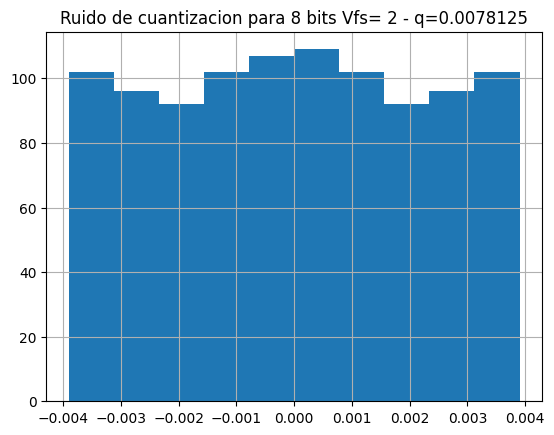

In [37]:
# %% ruido cuantizado

#secuencia de error
xxq=np.round(xx/qq) *qq #quedan en la misma magnitud que la senoidal
ee=xxq-xx #secueencia de error

plt.figure(4)
plt.clf()
plt.grid()
plt.hist(ee)
plt.title(f"Ruido de cuantizacion para {b} bits Vfs= {vfs} - q={qq}")
plt.show()